# Supplementary Figure S3: ClinVar review-star robustness

**Purpose.** Evaluate whether AUROC conclusions remain stable under increasingly strict ClinVar review-star thresholds.

## Reproducibility contract

- **Run from:** the repository root.
- **Input:** `data/processed/clinvar_benchmark_updated.csv` (the full scored benchmark; not stored in GitHub).
- **Outputs:** `results/tables/figure_s3_clinvar_stars_*.csv`, `results/figures/figure_s3.svg`, and a diagnostic heatmap.
- **Randomness:** 200 stratified bootstrap replicates per comparison, seed 42.
- **Compute:** CPU; no model inference is performed.


## 1. Setup


In [1]:
from pathlib import Path
import pandas as pd

# Run this notebook from the repository root.
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
MODEL_SCORE_DIR = DATA_DIR / "model_scores"
RESULTS_DIR = REPO_ROOT / "results"
TABLE_DIR = RESULTS_DIR / "tables"
FIGURE_DIR = RESULTS_DIR / "figures"
SCORED_BENCHMARK_PATH = DATA_DIR / "processed" / "clinvar_benchmark_updated.csv"
RANDOM_SEED = 42

def read_table(path, required_columns=()):
    """Read a local table and verify that required columns are present."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}. See README.md.")
    frame = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(
        path, low_memory=False, dtype={"#CHROM": str}
    )
    missing = sorted(set(required_columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    return frame

def validate_output_files(paths):
    """Verify that every expected output was created and is not empty."""
    for value in paths:
        path = Path(value)
        if not path.exists() or path.stat().st_size == 0:
            raise RuntimeError(f"Expected output was not created: {path}")
    print(f"Validated {len(paths)} output file(s).")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load and inspect input


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

pd.set_option("display.max_columns", 80)

DATA_PATH = SCORED_BENCHMARK_PATH
OUT_CSV = TABLE_DIR / "figure_s3_clinvar_stars_auroc.csv"
OUT_FIGURE = FIGURE_DIR / "figure_s3.svg"
OUT_HEATMAP = FIGURE_DIR / "figure_s3_clinvar_stars_heatmap.svg"

data = pd.read_csv(DATA_PATH)
print(f"Loaded {len(data):,} variants from {DATA_PATH.relative_to(REPO_ROOT)}")
print("ClinVar_gold_stars value counts (NaN = no assertion criteria provided):")
print(data["ClinVar_gold_stars"].value_counts(dropna=False).sort_index())


Loaded 242,132 variants from data/processed/clinvar_benchmark_updated.csv
ClinVar_gold_stars value counts (NaN = no assertion criteria provided):
ClinVar_gold_stars
1.0    128967
2.0    106789
3.0      6357
4.0        19
Name: count, dtype: int64


/var/folders/w5/rvfhv_qx0474bc17p1kxctd00000gn/T/ipykernel_31007/1932062257.py:16: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(DATA_PATH)


## 3. Define the analysis


In [3]:
# Models, subgroups, and sign-flipping conventions are shared with VEP_AUROC_figure.ipynb.

# Protein models split into two tiers:
#   esm_models       : ESM1b, ESM1v, ESM2, VESM++ (missense, stop gain, start loss, combinations)
#   specialist_models : AlphaMissense, PrimateAI_3D (missense, stop gain, combinations only)
esm_models       = ["ESM1b", "ESM1v", "ESM2", "vesm_score"]
specialist_models = ["AlphaMissense", "PrimateAI_3D"]
protein_models   = esm_models + specialist_models

tools = [
    "PhyloP", "Evo2_7B", "Evo2_40B", "AlphaGenome_quantile", "Rule_based",
    "GPN_MSA", "PhyloGPN", "gpnstar_v_llr", "DNABERT2",
    "ntv3_pre_position_llr",
    "ntv3_post_log2fc_max",
    "ESM1b", "ESM1v", "ESM2", "vesm_score",
    "AlphaMissense", "PrimateAI_3D",
]

# Models whose raw score already has higher = more pathogenic; all others are sign-flipped.
NO_FLIP = {
    "PhyloP", "DNABERT2",
    "AlphaMissense", "PrimateAI_3D", "AlphaGenome_quantile", "Rule_based",
    "ntv3_post_log2fc_max",
}

# Index boundaries (0-based): tools[0:12] = DNA-only, tools[0:16] = +ESM, tools[:] = all
_DNA = tools[:11]
_ESM = tools[:15]
_ALL = tools[:]

# Variant subgroups and which models apply.
subgroups = [
    "group: missense",                       # all models
    "group: missense + 3'UTR",               # all models
    "group: missense + intron (non-splice)", # all models
    "group: stop gain",                      # all models
    "group: start loss",                     # DNA + ESM only (no AlphaMissense/PrimateAI-3D)
    "group: noncoding",                      # DNA only
    "group: stop loss",                      # DNA only
    "group: synonymous",                     # DNA only
    "group: 5'UTR",                          # DNA only
    "group: 3'UTR",                          # DNA only
    "group: 3'UTR + RNA gene",               # DNA only
    "group: splice",                         # DNA only
    "group: intron (non-splice)",            # DNA only
    "group: RNA gene",                       # DNA only
]

TOOLS_PER_SUBGROUP = {}
for i, sg in enumerate(subgroups):
    if i in (0, 1, 2, 3):
        TOOLS_PER_SUBGROUP[sg] = _ALL   # missense, stop gain, combinations — all models
    elif i == 4:
        TOOLS_PER_SUBGROUP[sg] = _ESM   # start loss — DNA + ESM only
    else:
        TOOLS_PER_SUBGROUP[sg] = _DNA   # noncoding subgroups — DNA only

rename_dict = {
    "Evo2_7B":               "Evo2 7B",
    "Evo2_40B":              "Evo2 40B",
    "DNABERT2":              "DNABERT2",
    "PhyloP":                "PhyloP",
    "AlphaGenome_quantile":  "AlphaGenome",
    "GPN_MSA":               "GPN-MSA",
    "PhyloGPN":              "PhyloGPN",
    "gpnstar_v_llr":         "GPN-Star",
    "ntv3_pre_position_llr": "NTv3-pre LLR",
    "ntv3_post_log2fc_max":  "NTv3-post log2FC",
    "ESM1b":                 "ESM1b",
    "ESM1v":                 "ESM1v",
    "ESM2":                  "ESM2",
    "vesm_score":            "VESM++",
    "PrimateAI_3D":          "PrimateAI-3D",
    "AlphaMissense":         "AlphaMissense",
    "Rule_based":            "Rule-based",
}
palette = {
    "Evo2 7B":                "#e56b6f",
    "Evo2 40B":               "#c93735",
    "DNABERT2":               "#1b78b2",
    "NTv3-pre LLR":           "#6baed6",
    "NTv3-post log2FC":       "#54278f",
    "GPN-Star":               "#20b2aa",
    "PhyloP":                 "#808080",
    "GPN-MSA":                "#859ed7",
    "PhyloGPN":               "#f47f1e",
    "AlphaGenome":            "#a2d94d",
    "ESM1b":                  "#2da248",
    "ESM1v":                  "#8f69c5",
    "ESM2":                   "#22bdd2",
    "VESM++":                 "#e377c2",
    "PrimateAI-3D":           "#d26101",
    "AlphaMissense":          "#333a8c",
    "Rule-based":             "#b0b0b0",
}
display_map = {
    "group: noncoding":                      "Noncoding",
    "group: intron (non-splice)":            "Intron (Non-splice)",
    "group: splice":                         "Splice",
    "group: 5'UTR":                          "5' UTR",
    "group: 3'UTR":                          "3' UTR",
    "group: 3'UTR + RNA gene":               "3' UTR + RNA gene",
    "group: RNA gene":                       "RNA gene",
    "group: synonymous":                     "Synonymous",
    "group: start loss":                     "Start loss",
    "group: stop loss":                      "Stop loss",
    "group: missense":                       "Missense",
    "group: missense + intron (non-splice)": "Missense & Intron (Non-splice)",
    "group: missense + 3'UTR":               "Missense & 3'UTR",
    "group: stop gain":                      "Stop gain",
}


In [4]:
# ClinVar review-star thresholds used in Supplementary Figure S3.
# The complete benchmark already contains variants with at least one review star,
# so the unfiltered benchmark and the >=1-star subset are identical. We therefore
# show only the three nonredundant thresholds.

def star_mask(df, cutoff):
    return df["ClinVar_gold_stars"] >= cutoff


cutoffs = [
    (">=1 star", 1),
    (">=2 stars", 2),
    (">=3 stars", 3),
]

summary = []
for label, cutoff in cutoffs:
    subset = data.loc[star_mask(data, cutoff)]
    n_pathogenic = int(subset["ClinVar_label"].sum())
    summary.append({
        "cutoff": label,
        "N": len(subset),
        "pathogenic": n_pathogenic,
        "benign": len(subset) - n_pathogenic,
        "%P": round(100 * n_pathogenic / len(subset), 2) if len(subset) else np.nan,
    })
pd.DataFrame(summary)


,cutoff,N,pathogenic,benign,%P
0,>=1 star,242132,69515,172617,28.71
1,>=2 stars,113165,22089,91076,19.52
2,>=3 stars,6376,3899,2477,61.15


In [5]:
# AUROC helpers (bootstrap CI reused from the main notebook).

N_BOOTSTRAPS = 200


def bootstrap_auc_ci(y, s, n_boot=N_BOOTSTRAPS, seed=42):
    y = np.asarray(y).astype(int)
    s = np.asarray(s).astype(float)
    n = len(y)
    if n == 0 or len(np.unique(y)) < 2:
        return np.nan, np.nan, np.nan
    auc_hat = roc_auc_score(y, s)
    rng = np.random.default_rng(seed)
    class_indices = [np.flatnonzero(y == label) for label in (0, 1)]
    aucs = []
    for _ in range(n_boot):
        idx = np.concatenate([
            rng.choice(indices, size=len(indices), replace=True)
            for indices in class_indices
        ])
        aucs.append(roc_auc_score(y[idx], s[idx]))
    if len(aucs) < max(30, 0.5 * n_boot):
        return float(auc_hat), np.nan, np.nan
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    return float(auc_hat), float(lo), float(hi)

MIN_PER_CLASS = 5  # minimum positives and negatives required to compute AUROC

def compute_auroc_table(df, tools_per_sg, n_boot=200):
    rows = []
    for sg, sg_tools in tools_per_sg.items():
        sg_df = df[df[sg] == 1]
        sg_df = sg_df[sg_df[sg_tools].notna().all(axis=1)]
        y = sg_df["ClinVar_label"].astype(int)
        n = len(sg_df); npos = int(y.sum()); nneg = n - npos
        for tool in sg_tools:
            if npos < MIN_PER_CLASS or nneg < MIN_PER_CLASS:
                auc, lo, hi = np.nan, np.nan, np.nan
            else:
                auc, lo, hi = bootstrap_auc_ci(y, sg_df[tool].values, n_boot=n_boot)
                if tool not in NO_FLIP and not np.isnan(auc):
                    auc = 1 - auc
                    if not np.isnan(lo) and not np.isnan(hi):
                        lo, hi = 1 - hi, 1 - lo
            rows.append({
                "subgroup": sg, "tool": tool,
                "N": n, "N_pos": npos, "N_neg": nneg,
                "AUROC": auc, "CI_low": lo, "CI_high": hi,
            })
    return pd.DataFrame(rows)


In [6]:
# Run the benchmark at every cutoff.
# This is the main computation. Expect ~1-2 minutes.

all_results = []
for label, cut in cutoffs:
    mask = star_mask(data, cut)
    sub = data.loc[mask].copy()
    print(f"[{label}] N={len(sub):,}  %P={100 * sub['ClinVar_label'].mean():.2f}%")
    res = compute_auroc_table(sub, TOOLS_PER_SUBGROUP, n_boot=N_BOOTSTRAPS)
    res.insert(0, "cutoff", label)
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)
results_df["model"] = results_df["tool"].map(rename_dict)
results_df.to_csv(OUT_CSV, index=False)
print(f"\nSaved full results table to {OUT_CSV.relative_to(REPO_ROOT)}: {len(results_df):,} rows")
results_df.head()


[>=1 star] N=242,132  %P=28.71%


[>=2 stars] N=113,165  %P=19.52%


[>=3 stars] N=6,376  %P=61.15%



Saved full results table to results/tables/figure_s3_clinvar_stars_auroc.csv: 546 rows


,cutoff,subgroup,tool,N,N_pos,N_neg,AUROC,CI_low,CI_high,model
0,>=1 star,group: missense,PhyloP,37076,13705,23371,0.869385,0.865877,0.873025,PhyloP
1,>=1 star,group: missense,Evo2_7B,37076,13705,23371,0.835707,0.831473,0.839750,Evo2 7B
2,>=1 star,group: missense,Evo2_40B,37076,13705,23371,0.845441,0.841295,0.849621,Evo2 40B
3,>=1 star,group: missense,AlphaGenome_quantile,37076,13705,23371,0.550094,0.544164,0.556188,AlphaGenome
4,>=1 star,group: missense,Rule_based,37076,13705,23371,0.500000,0.500000,0.500000,Rule-based


## 4. Render figures and summarize stability


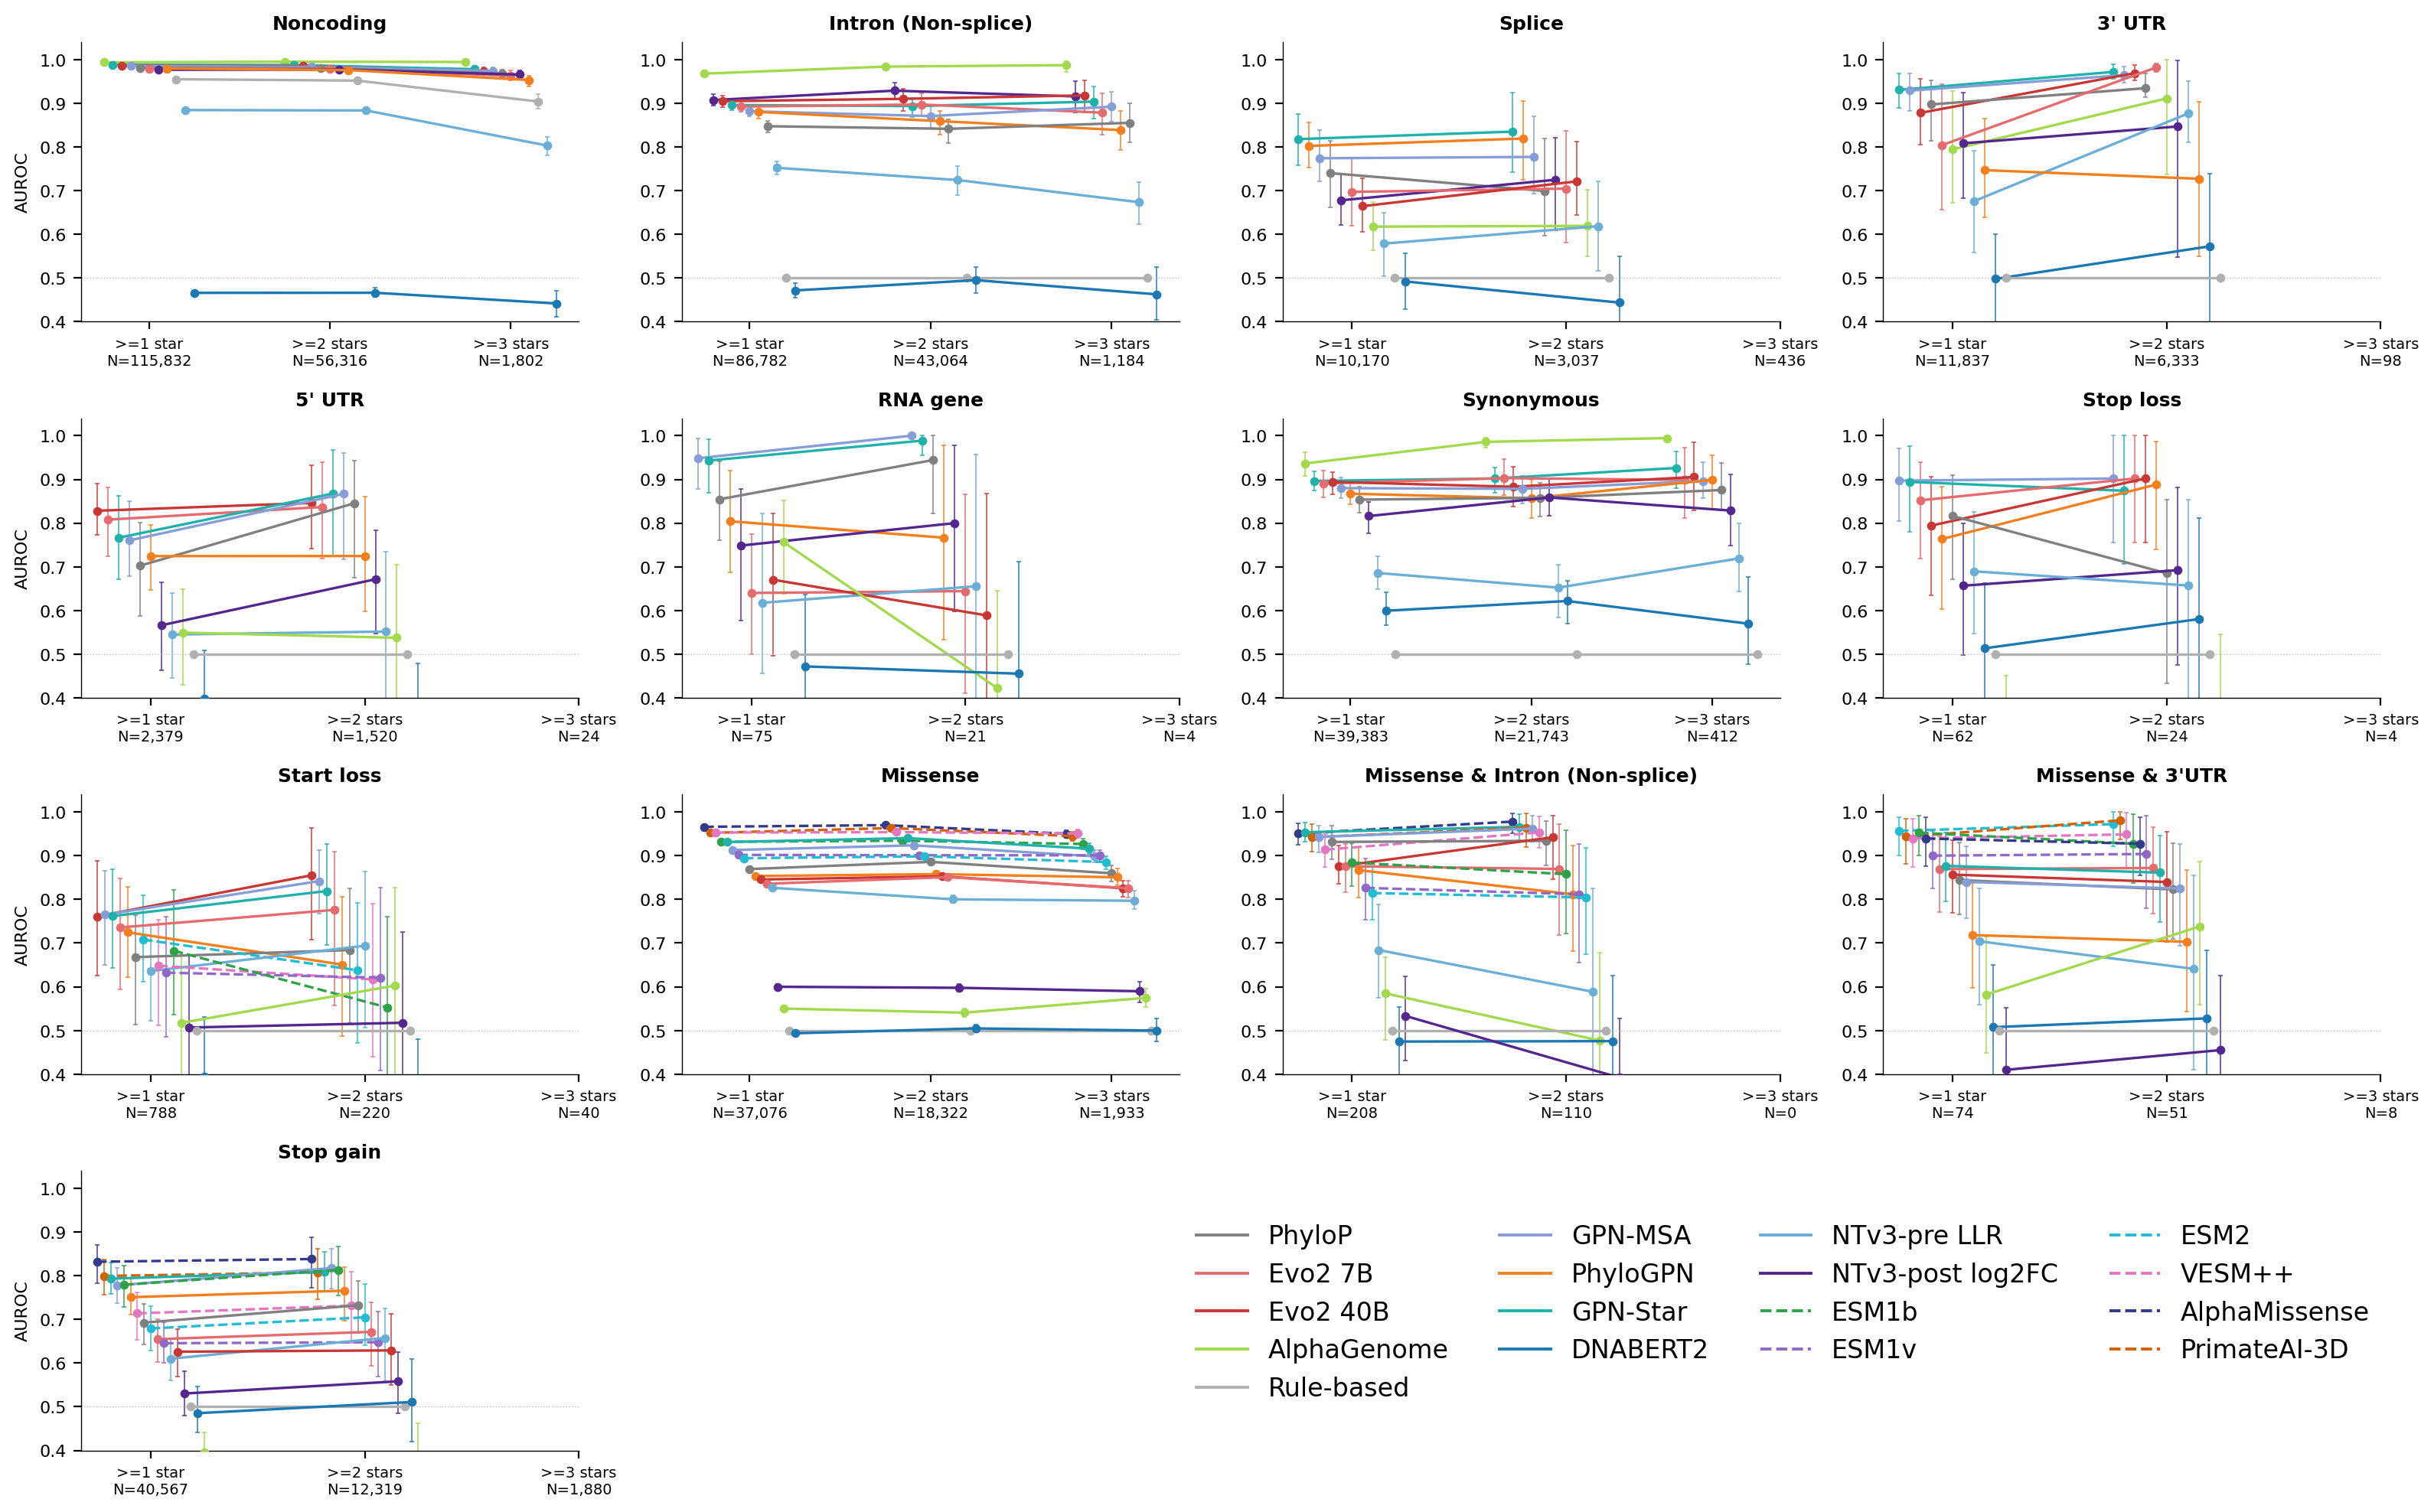

Saved: results/figures/figure_s3.svg


In [2]:
# Robustness figure: AUROC vs star cutoff, one panel per variant type.
# Each model is drawn as a line + markers; vertical whiskers at each marker
# show the 95% bootstrap CI from `compute_auroc_table`. Because up to 13
# models can share the same panel, model x-positions are slightly jittered so
# the whiskers do not stack on top of each other.

ordered_subgroups = [
    "group: noncoding", "group: intron (non-splice)", "group: splice",
    "group: 3\'UTR", "group: 5\'UTR", "group: RNA gene",
    "group: synonymous", "group: stop loss", "group: start loss",
    "group: missense", "group: missense + intron (non-splice)",
    "group: missense + 3\'UTR", "group: stop gain",
]

FONT_SIZE = 8
FONT_NAME = "DejaVu Sans"
dashed_models = {"ESM1b", "ESM1v", "ESM2", "AlphaMissense", "PrimateAI-3D", "VESM++"}

cutoff_labels = [c[0] for c in cutoffs]
cutoff_x = np.arange(len(cutoff_labels))

ncols = 4
nrows = int(np.ceil(len(ordered_subgroups) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.6 * nrows), dpi=200)
axes = axes.flatten()

for i, sg in enumerate(ordered_subgroups):
    ax = axes[i]
    sg_df = results_df[results_df["subgroup"] == sg]
    if sg_df.empty:
        ax.axis("off")
        continue
    models_in_sg = sorted(sg_df["model"].dropna().unique(),
                          key=lambda m: -sg_df.loc[sg_df["model"] == m, "AUROC"].mean(skipna=True))

    n_models = len(models_in_sg)
    if n_models > 1:
        x_offsets = (np.arange(n_models) - (n_models - 1) / 2.0) * (0.5 / max(n_models - 1, 1))
    else:
        x_offsets = np.array([0.0])

    for k, m in enumerate(models_in_sg):
        sub = sg_df[sg_df["model"] == m].set_index("cutoff").reindex(cutoff_labels)
        ys = sub["AUROC"].values.astype(float)
        los = sub["CI_low"].values.astype(float)
        his = sub["CI_high"].values.astype(float)
        color = palette.get(m, "#444444")
        ls = "--" if m in dashed_models else "-"

        x_jit = cutoff_x + x_offsets[k]

        # Connecting line + markers (NaN points are dropped by matplotlib)
        ax.plot(x_jit, ys, marker="o", markersize=3.2, lw=1.2,
                color=color, linestyle=ls, label=m, zorder=3)

        # 95% CI whiskers, drawn only where both bounds are present
        ci_mask = ~np.isnan(ys) & ~np.isnan(los) & ~np.isnan(his)
        if ci_mask.any():
            yerr = np.vstack([
                np.maximum(ys[ci_mask] - los[ci_mask], 0.0),
                np.maximum(his[ci_mask] - ys[ci_mask], 0.0),
            ])
            ax.errorbar(
                x_jit[ci_mask], ys[ci_mask], yerr=yerr,
                fmt="none", ecolor=color,
                elinewidth=0.7, capsize=1.2, capthick=0.7,
                alpha=0.75, zorder=2,
            )

    # annotate sample size for each cutoff
    ns = [sg_df[sg_df["cutoff"] == lbl]["N"].max() for lbl in cutoff_labels]
    xt_labels = [f"{lbl}\nN={int(n):,}" if pd.notna(n) else f"{lbl}\nN=0"
                 for lbl, n in zip(cutoff_labels, ns)]
    ax.set_xticks(cutoff_x)
    ax.set_xticklabels(xt_labels, fontsize=FONT_SIZE - 1, fontname=FONT_NAME)
    ax.tick_params(axis="y", labelsize=FONT_SIZE)
    ax.set_ylim(0.40, 1.04)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.1))
    ax.axhline(0.5, color="#bbbbbb", lw=0.5, ls=":")
    ax.set_title(display_map.get(sg, sg), fontsize=FONT_SIZE + 1,
                 fontname=FONT_NAME, fontweight="bold")
    if i % ncols == 0:
        ax.set_ylabel("AUROC", fontsize=FONT_SIZE, fontname=FONT_NAME)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)
    ax.spines["left"].set_linewidth(0.5)

for j in range(len(ordered_subgroups), len(axes)):
    axes[j].axis("off")

# shared legend
legend_models = [
    "PhyloP", "Evo2 7B", "Evo2 40B", "AlphaGenome", "Rule-based",
    "GPN-MSA", "PhyloGPN", "GPN-Star", "DNABERT2",
    "NTv3-pre LLR", "NTv3-post log2FC",
    "ESM1b", "ESM1v", "ESM2", "VESM++", "AlphaMissense", "PrimateAI-3D",
]

handles = []
for m in legend_models:
    ls = "--" if m in dashed_models else "-"
    handles.append(plt.Line2D([0], [0], color=palette[m], lw=1.4, linestyle=ls, label=m))
fig.legend(handles=handles, loc="lower right", ncol=4, fontsize=FONT_SIZE+4,
           frameon=False, bbox_to_anchor=(0.98, 0.1))

fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(OUT_FIGURE, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIGURE.relative_to(REPO_ROOT)}")


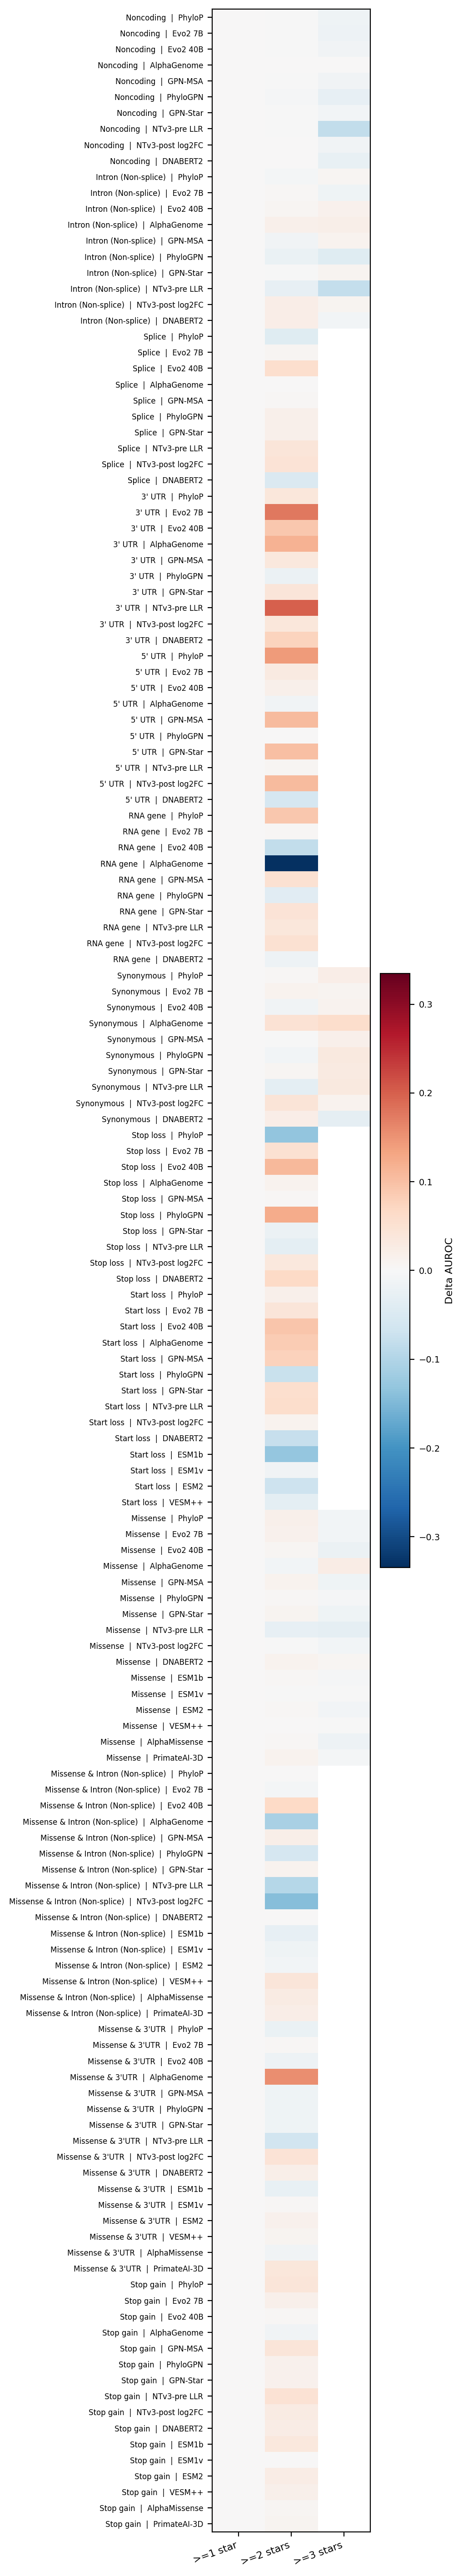

Saved: results/figures/figure_s3_clinvar_stars_heatmap.svg


In [3]:
# Stability heatmap: delta AUROC relative to the >=1-star benchmark.

pivot = results_df.pivot_table(
    index=["subgroup", "model"], columns="cutoff", values="AUROC", aggfunc="first"
)
pivot = pivot.reindex(columns=cutoff_labels)
delta = pivot.subtract(pivot[">=1 star"], axis=0)

heat_subgroups = [sg for sg in ordered_subgroups if sg in pivot.index.get_level_values(0)]
model_order = [
    "PhyloP", "Evo2 7B", "Evo2 40B", "AlphaGenome", "GPN-MSA", "PhyloGPN", "GPN-Star",
    "NTv3-pre LLR", "NTv3-pre PLLR", "NTv3-post LLR", "NTv3-post PLLR", "NTv3-post log2FC",
    "DNABERT2", "ESM1b", "ESM1v", "ESM2", "VESM++", "AlphaMissense", "PrimateAI-3D",
]

plot_rows = []
row_labels = []
for subgroup in heat_subgroups:
    for model in model_order:
        if (subgroup, model) in delta.index:
            plot_rows.append(delta.loc[(subgroup, model)].values)
            row_labels.append(f"{display_map.get(subgroup, subgroup)}  |  {model}")

plot_arr = np.array(plot_rows, dtype=float)
fig2, ax2 = plt.subplots(figsize=(5.2, max(6, 0.18 * len(plot_rows))), dpi=200)
vmax = float(np.nanmax(np.abs(plot_arr))) if np.isfinite(plot_arr).any() else 0.1
vmax = max(vmax, 0.05)
im = ax2.imshow(plot_arr, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax2.set_xticks(range(len(cutoff_labels)))
ax2.set_xticklabels(cutoff_labels, fontsize=FONT_SIZE, fontname=FONT_NAME, rotation=20, ha="right")
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels, fontsize=FONT_SIZE - 2, fontname=FONT_NAME)
cbar = fig2.colorbar(im, ax=ax2, shrink=0.6)
cbar.ax.tick_params(labelsize=FONT_SIZE - 1)
cbar.set_label("Delta AUROC", fontsize=FONT_SIZE, fontname=FONT_NAME)
fig2.tight_layout()
fig2.savefig(OUT_HEATMAP, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_HEATMAP.relative_to(REPO_ROOT)}")


In [9]:
# Numerical stability summary across the three displayed thresholds.

def summarize_stability(pivot_df):
    rows = []
    for (subgroup, model), row in pivot_df.iterrows():
        values = row.dropna().values.astype(float)
        if len(values) < 2:
            continue
        rows.append({
            "subgroup": display_map.get(subgroup, subgroup),
            "model": model,
            "AUROC_ge1_star": row.get(">=1 star", np.nan),
            "AUROC_min": float(np.min(values)),
            "AUROC_max": float(np.max(values)),
            "AUROC_range": float(np.max(values) - np.min(values)),
            "n_cutoffs_available": int(len(values)),
        })
    return pd.DataFrame(rows).sort_values(["subgroup", "model"]).reset_index(drop=True)


stability_df = summarize_stability(pivot)
stability_df.to_csv(TABLE_DIR / "figure_s3_clinvar_stars_stability.csv", index=False)
print("Median AUROC range:", f"{stability_df['AUROC_range'].median():.4f}")
print("95th percentile of AUROC range:", f"{stability_df['AUROC_range'].quantile(0.95):.4f}")
stability_df.head(20)


Median AUROC range: 0.0240
95th percentile of AUROC range: 0.1205


,subgroup,model,AUROC_ge1_star,AUROC_min,AUROC_max,AUROC_range,n_cutoffs_available
0,3' UTR,AlphaGenome,0.794496,0.794496,0.910936,0.116440,2
1,3' UTR,DNABERT2,0.498009,0.498009,0.572408,0.074399,2
2,3' UTR,Evo2 40B,0.877928,0.877928,0.968584,0.090657,2
3,3' UTR,Evo2 7B,0.803942,0.803942,0.981511,0.177569,2
4,3' UTR,GPN-MSA,0.928711,0.928711,0.964159,0.035448,2
5,3' UTR,GPN-Star,0.930428,0.930428,0.971523,0.041095,2
6,3' UTR,NTv3-post log2FC,0.808265,0.808265,0.846618,0.038353,2
7,3' UTR,NTv3-pre LLR,0.675822,0.675822,0.876391,0.200568,2
8,3' UTR,PhyloGPN,0.746786,0.727086,0.746786,0.019700,2
9,3' UTR,PhyloP,0.897145,0.897145,0.934213,0.037068,2


## Interpretation

We compare the benchmark at three nonredundant ClinVar review thresholds: at least one, two, or three review stars. The complete benchmark is already restricted to variants with at least one star, so an additional "All variants" category would duplicate the first x-axis value exactly.

The three-star subset is much smaller and some variant types no longer contain enough benign and pathogenic examples for a reliable AUROC. Those estimates are reported as missing rather than extrapolated. The saved stability table provides the AUROC range for every model and variant type with at least two estimable thresholds.


## 5. Validate outputs


In [10]:

validate_output_files([
    TABLE_DIR / "figure_s3_clinvar_stars_auroc.csv",
    TABLE_DIR / "figure_s3_clinvar_stars_stability.csv",
    FIGURE_DIR / "figure_s3.svg",
    FIGURE_DIR / "figure_s3_clinvar_stars_heatmap.svg",
])


Validated 4 output file(s).
